In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

DATA_PATH = r"C:\Users\HP\Downloads\Financial_Performance_Budget_vs_Actual (1).csv"  
PLOTS_DIR = "eda_plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

In [47]:
# DATA LOAD

df = pd.read_csv(DATA_PATH, parse_dates=['Date'])
print("Shape:", df.shape)
df.head()

Shape: (1296, 8)


,Date,Year,Month,Region,Department,Account_Category,Budgeted_Amount,Actual_Amount
0,2022-01-01,2022,Jan,North,Sales,Revenue,2400000,2213645
1,2022-01-01,2022,Jan,North,Sales,COGS,1200000,1191704
2,2022-01-01,2022,Jan,North,Sales,OpEx,120000,123886
3,2022-01-01,2022,Jan,North,Marketing,OpEx,180000,193707
4,2022-01-01,2022,Jan,North,Operations,OpEx,144000,142314


In [49]:
# Data Quality Check

print("--- Nulls ---")
print(df.isnull().sum())

print("\n--- Duplicates ---", df.duplicated().sum())

print("\n--- Dtypes ---")
print(df.dtypes)

print("\n--- Negative amounts ---")
print("Budget:", (df['Budgeted_Amount'] < 0).sum(), "| Actual:", (df['Actual_Amount'] < 0).sum())

print("\n--- Unique categorical values ---")
for col in ['Region', 'Department', 'Account_Category']:
    print(f"{col}: {df[col].unique()}")

--- Nulls ---
Date                0
Year                0
Month               0
Region              0
Department          0
Account_Category    0
Budgeted_Amount     0
Actual_Amount       0
dtype: int64

--- Duplicates --- 0

--- Dtypes ---
Date                datetime64[ns]
Year                         int64
Month                       object
Region                      object
Department                  object
Account_Category            object
Budgeted_Amount              int64
Actual_Amount                int64
dtype: object

--- Negative amounts ---
Budget: 0 | Actual: 0

--- Unique categorical values ---
Region: ['North' 'South' 'East' 'West']
Department: ['Sales' 'Marketing' 'Operations' 'R&D' 'Admin']
Account_Category: ['Revenue' 'COGS' 'OpEx' 'CapEx']


In [51]:
# KPIs Banana (Variance % + Profit Margin)

df['Variance_Amount'] = df['Actual_Amount'] - df['Budgeted_Amount']
df['Variance_Pct'] = (df['Variance_Amount'] / df['Budgeted_Amount']) * 100

monthly_pnl = (
    df.groupby(['Date', 'Region', 'Account_Category'])['Actual_Amount']
    .sum()
    .unstack('Account_Category')
    .fillna(0)
    .reset_index()
)
monthly_pnl['Operating_Profit'] = (
    monthly_pnl['Revenue'] - monthly_pnl['COGS'] - monthly_pnl['OpEx']
)
monthly_pnl['Profit_Margin_Pct'] = (monthly_pnl['Operating_Profit'] / monthly_pnl['Revenue']) * 100

monthly_pnl.head()

Account_Category,Date,Region,COGS,CapEx,OpEx,Revenue,Operating_Profit,Profit_Margin_Pct
0,2022-01-01,East,942420,291259,515360,1460536,2756,0.188698
1,2022-01-01,North,1191704,424097,633797,2213645,388144,17.534157
2,2022-01-01,South,976829,325155,496700,1848830,375301,20.299379
3,2022-01-01,West,1093184,359369,519757,1874714,261773,13.963357
4,2022-02-01,East,994914,309727,545324,1508277,-31961,-2.119040


In [53]:
# Overall KPI Summary 


total_revenue = df.loc[df['Account_Category'] == 'Revenue', 'Actual_Amount'].sum()
total_cogs_opex = df.loc[df['Account_Category'].isin(['COGS', 'OpEx']), 'Actual_Amount'].sum()
total_capex = df.loc[df['Account_Category'] == 'CapEx', 'Actual_Amount'].sum()
operating_profit = total_revenue - total_cogs_opex
profit_margin = (operating_profit / total_revenue) * 100
overall_variance_pct = (
    (df['Actual_Amount'].sum() - df['Budgeted_Amount'].sum()) / df['Budgeted_Amount'].sum() * 100
)

print(f"Total Revenue          : Rs. {total_revenue:,.0f}")
print(f"Total COGS + OpEx      : Rs. {total_cogs_opex:,.0f}")
print(f"Operating Profit       : Rs. {operating_profit:,.0f}")
print(f"Operating Profit Margin: {profit_margin:.2f}%")
print(f"Total CapEx (separate) : Rs. {total_capex:,.0f}")
print(f"Overall Budget Var %   : {overall_variance_pct:.2f}%")

Total Revenue          : Rs. 354,243,676
Total COGS + OpEx      : Rs. 266,405,052
Operating Profit       : Rs. 87,838,624
Operating Profit Margin: 24.80%
Total CapEx (separate) : Rs. 76,506,464
Overall Budget Var %   : 7.18%


Account_Category   COGS  CapEx   OpEx  Revenue
Region                                        
East              17.87  28.00  23.59     5.62
North              0.79  30.52   2.67     5.06
South             -2.03  30.20   2.75     6.40
West               0.44  29.75   2.36     3.53


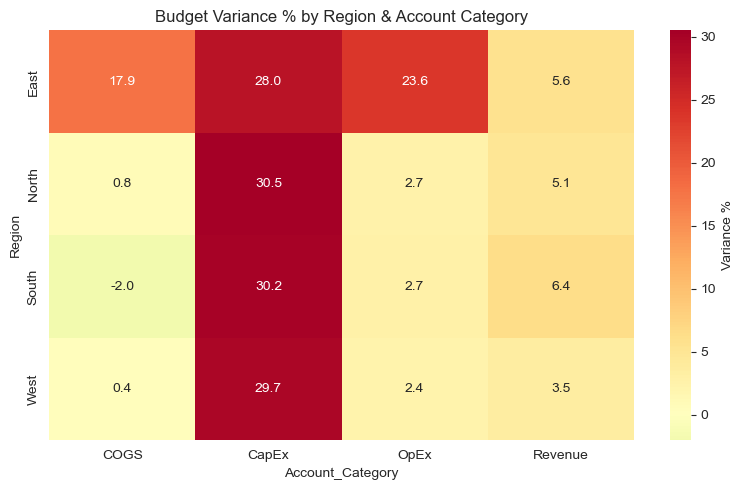

In [55]:
# Variance Heatmap 

pivot_variance = (
    df.groupby(['Region', 'Account_Category'])
    .apply(lambda g: (g['Actual_Amount'].sum() - g['Budgeted_Amount'].sum()) / g['Budgeted_Amount'].sum() * 100,
           include_groups=False)
    .unstack()
)
print(pivot_variance.round(2))

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_variance, annot=True, fmt=".1f", cmap="RdYlGn_r", center=0,
            cbar_kws={'label': 'Variance %'})
plt.title("Budget Variance % by Region & Account Category")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/variance_heatmap.png", dpi=150)
plt.show()

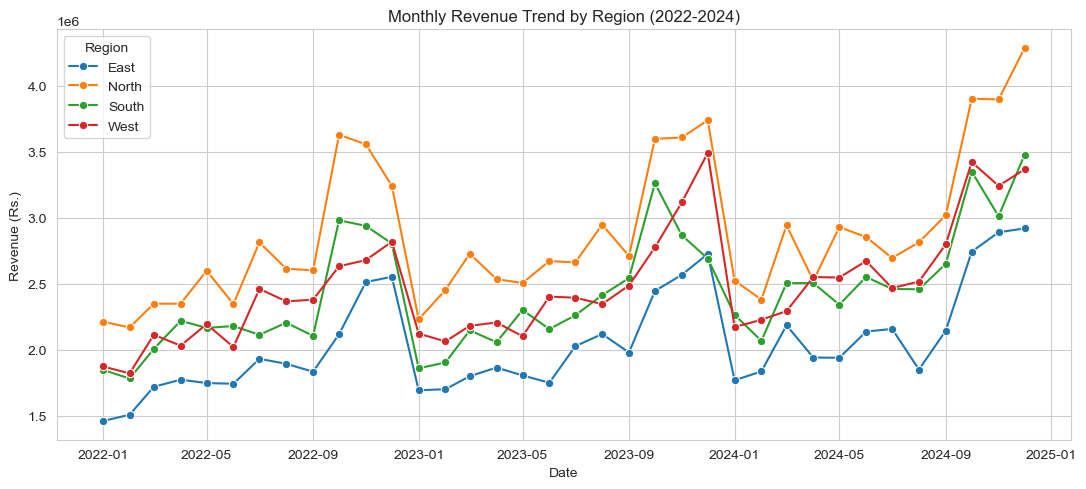

In [57]:
# Revenue Trend (Region-wise, time ke saath)

revenue_trend = (
    df[df['Account_Category'] == 'Revenue']
    .groupby(['Date', 'Region'])['Actual_Amount'].sum()
    .reset_index()
)

plt.figure(figsize=(11, 5))
sns.lineplot(data=revenue_trend, x='Date', y='Actual_Amount', hue='Region', marker='o')
plt.title("Monthly Revenue Trend by Region (2022-2024)")
plt.ylabel("Revenue (Rs.)")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/revenue_trend.png", dpi=150)
plt.show()

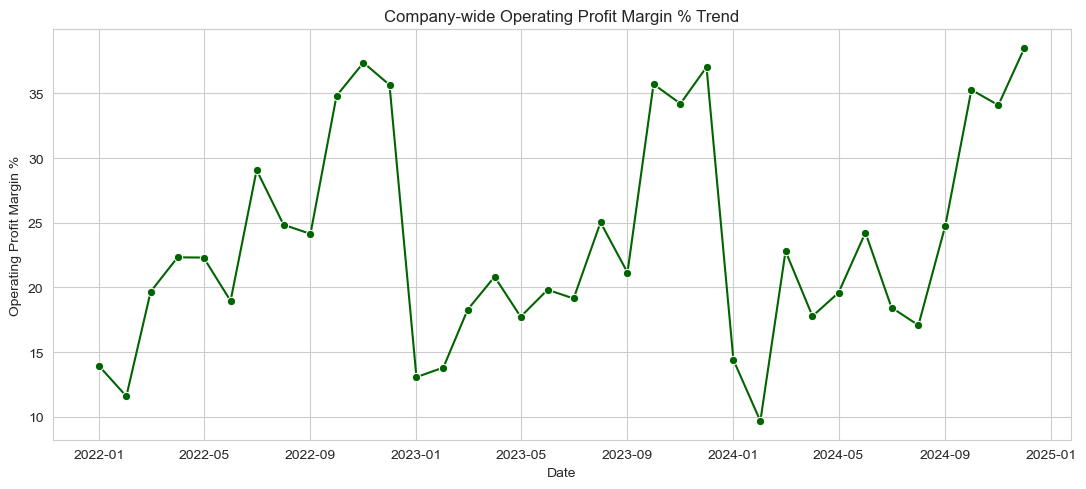

In [59]:
# Profit Margin Trend

company_monthly = monthly_pnl.groupby('Date')[['Revenue', 'Operating_Profit']].sum().reset_index()
company_monthly['Profit_Margin_Pct'] = company_monthly['Operating_Profit'] / company_monthly['Revenue'] * 100

plt.figure(figsize=(11, 5))
sns.lineplot(data=company_monthly, x='Date', y='Profit_Margin_Pct', marker='o', color='darkgreen')
plt.title("Company-wide Operating Profit Margin % Trend")
plt.ylabel("Operating Profit Margin %")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/profit_margin_trend.png", dpi=150)
plt.show()

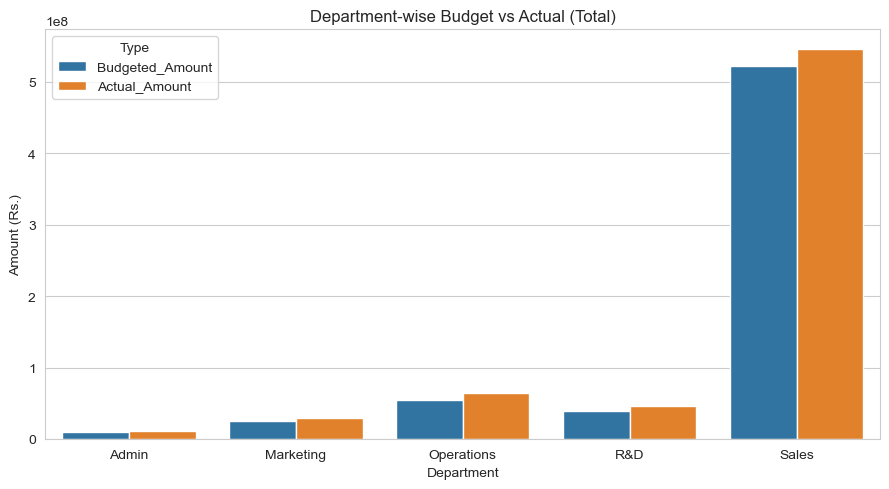

In [61]:
# Department-wise Budget vs Actual

dept_summary = df.groupby('Department')[['Budgeted_Amount', 'Actual_Amount']].sum().reset_index()
dept_summary_melt = dept_summary.melt(id_vars='Department', var_name='Type', value_name='Amount')

plt.figure(figsize=(9, 5))
sns.barplot(data=dept_summary_melt, x='Department', y='Amount', hue='Type')
plt.title("Department-wise Budget vs Actual (Total)")
plt.ylabel("Amount (Rs.)")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/department_budget_vs_actual.png", dpi=150)
plt.show()

In [63]:
# Top 5 Most Over-Budget Combinations

combo_variance = (
    df.groupby(['Region', 'Department', 'Account_Category'])
    .agg(Budget=('Budgeted_Amount', 'sum'), Actual=('Actual_Amount', 'sum'))
    .reset_index()
)
combo_variance['Variance_Pct'] = (
    (combo_variance['Actual'] - combo_variance['Budget']) / combo_variance['Budget'] * 100
)
top_over_budget = combo_variance.sort_values('Variance_Pct', ascending=False).head(5)
print(top_over_budget[['Region', 'Department', 'Account_Category', 'Variance_Pct']])

   Region  Department Account_Category  Variance_Pct
1    East   Marketing             OpEx     32.247333
20  South  Operations            CapEx     31.551342
13  North         R&D            CapEx     31.328480
31   West         R&D            CapEx     30.470733
11  North  Operations            CapEx     29.916548
